# 11) Experimentos por Algoritmo Evolutivo

**Objetivo:** Para cada uno de los 4 algoritmos del notebook `hyperopt_ga.ipynb`, correr **3 experimentos** que varien el hiperparametro mas relevante del algoritmo. Comparar resultados y extraer conclusiones.

| Algoritmo | Hiperparametro estudiado | Variantes |
|---|---|---|
| **GA canonico** | Presion selectiva + cxpb/mutpb | Baseline / Exploracion / Explotacion |
| **CMA-ES** | `sigma0` | 0.3 / 0.1 / 0.5 |
| **DE** | `F` (mutation) + `CR` (recombination) + `strategy` | Dithering / Exploit / Explore |
| **NSGA-II** | Objetivos + `cxpb` | (acc, n_params) / (acc, latencia) / (acc, n_params) con `cxpb=0.6` |

**Presupuesto:** `pop=6, gen=3, epochs=8, patience=2` por experimento (~24 evaluaciones por experimento × 12 = ~288 evaluaciones totales).

Los resultados de evaluacion se cachean entre algoritmos, asi que genomas ya evaluados se reutilizan.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import gc
import pickle
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack, csr_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1776801200.702328      24 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776801200.703899      24 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776801202.056251      24 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776801202.057291      24 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Pipeline de features (identico a `train.ipynb`)

In [2]:
_candidates = [
    "data/gender-classifier-clean.csv",
    "../data/gender-classifier-clean.csv",
    "/app/data/gender-classifier-clean.csv",
]
DATA_PATH = next(p for p in _candidates if os.path.exists(p))

df = pd.read_csv(DATA_PATH)
print(f"Archivo cargado desde: {DATA_PATH}  (shape = {df.shape})")

le = LabelEncoder()
y = le.fit_transform(df["gender"])

var_numericas = [
    "desc_length", "desc_word_count", "text_length", "text_word_count", "name_length",
    "fav_number", "tweet_count", "retweet_count",
    "fav_number_log", "tweet_count_log", "retweet_count_log",
    "link_color_r", "link_color_g", "link_color_b",
    "sidebar_color_r", "sidebar_color_g", "sidebar_color_b",
    "account_age_days", "created_year", "created_month",
]
X_numeric = df[var_numericas].values

TOP_N_TZ = 15
top_tz = df["user_timezone"].value_counts().head(TOP_N_TZ).index.tolist()
tz_grouped = df["user_timezone"].where(df["user_timezone"].isin(top_tz), other="other")
X_tz = pd.get_dummies(tz_grouped, prefix="tz", dtype=int).values

loc_freq = df["tweet_location"].value_counts(normalize=True)
X_loc = df["tweet_location"].map(loc_freq).values.reshape(-1, 1)

tfidf_desc = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_desc = tfidf_desc.fit_transform(df["description"].fillna(""))
tfidf_text = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_text = tfidf_text.fit_transform(df["text"].fillna(""))
tfidf_name = TfidfVectorizer(max_features=200, analyzer="char_wb", ngram_range=(2, 4), min_df=5)
X_name = tfidf_name.fit_transform(df["name"].fillna(""))

X_dense_sparse = np.hstack([X_numeric, X_tz, X_loc])
X = hstack([csr_matrix(X_dense_sparse), X_desc, X_text, X_name])

X_temp, X_test_3, y_temp, y_test_3 = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)
scaler_3 = MaxAbsScaler()
X_train_dense = scaler_3.fit_transform(X_train_3).toarray().astype("float32")
X_val_dense = scaler_3.transform(X_val_3).toarray().astype("float32")
X_test_dense = scaler_3.transform(X_test_3).toarray().astype("float32")

n_classes = len(le.classes_)
n_features = X_train_dense.shape[1]
y_train_oh = keras.utils.to_categorical(y_train_3, n_classes)
y_val_oh = keras.utils.to_categorical(y_val_3, n_classes)

classes_arr = np.array(sorted(np.unique(y_train_3)))
cw = compute_class_weight("balanced", classes=classes_arr, y=y_train_3)
class_weights = dict(zip(classes_arr.tolist(), cw.tolist()))

print(f"n_features = {n_features} | n_classes = {n_classes}")

Archivo cargado desde: data/gender-classifier-clean.csv  (shape = (18836, 26))
n_features = 1237 | n_classes = 3


## 2. Espacio de busqueda y funcion fitness

La funcion `evaluate_full` devuelve **(val_acc, latencia_ms, n_params)**, cacheados por genoma. De esta manera los experimentos de NSGA-II pueden usar cualquiera de los tres como objetivo sin re-entrenar.

In [3]:
PARAM_NAMES = ["n_hidden1", "n_hidden2", "dropout1", "dropout2", "lr", "batch_size", "leaky_alpha"]
BATCH_CHOICES = [64, 128, 256]
GENOME_SIZE = len(PARAM_NAMES)

EVAL_EPOCHS = 8
EVAL_PATIENCE = 2
LATENCY_REPS = 3
LATENCY_BATCH = 128


def decode(g):
    g = np.clip(np.asarray(g, dtype=float), 0.0, 1.0)
    return {
        "n_hidden1": int(round(64 + g[0] * (1024 - 64))),
        "n_hidden2": int(round(32 + g[1] * (512 - 32))),
        "dropout1": float(0.1 + g[2] * 0.5),
        "dropout2": float(0.1 + g[3] * 0.5),
        "lr": float(10.0 ** (-4 + g[4] * 2.0)),
        "batch_size": BATCH_CHOICES[min(int(g[5] * len(BATCH_CHOICES)),
                                         len(BATCH_CHOICES) - 1)],
        "leaky_alpha": float(g[6] * 0.1),
    }


def describe(params):
    return (f"h1={params['n_hidden1']:4d}  h2={params['n_hidden2']:4d}  "
            f"do1={params['dropout1']:.2f}  do2={params['dropout2']:.2f}  "
            f"lr={params['lr']:.1e}  bs={params['batch_size']:3d}  "
            f"leaky={params['leaky_alpha']:.3f}")


def num_params(params):
    h1, h2 = params["n_hidden1"], params["n_hidden2"]
    return ((n_features + 1) * h1 + 4 * h1
            + (h1 + 1) * h2 + 4 * h2
            + (h2 + 1) * n_classes)


def build_model(params):
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(params["n_hidden1"]),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=params["leaky_alpha"]),
        layers.Dropout(params["dropout1"]),
        layers.Dense(params["n_hidden2"]),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=params["leaky_alpha"]),
        layers.Dropout(params["dropout2"]),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["lr"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m


_EVAL_CACHE = {}
EVAL_LOG = []


def _genome_key(genome):
    return tuple(np.round(np.asarray(genome, dtype=float), 3))


def evaluate_full(genome, algo="?"):
    """Entrena la red y devuelve (val_acc, latency_ms, n_params). Cacheada."""
    key = _genome_key(genome)
    if key in _EVAL_CACHE:
        return _EVAL_CACHE[key]

    params = decode(genome)
    t0 = time.time()
    model = build_model(params)
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EVAL_PATIENCE, restore_best_weights=True
    )
    model.fit(
        X_train_dense, y_train_oh,
        validation_data=(X_val_dense, y_val_oh),
        epochs=EVAL_EPOCHS,
        batch_size=params["batch_size"],
        class_weight=class_weights,
        callbacks=[es],
        verbose=0,
    )
    val_loss, val_acc = model.evaluate(X_val_dense, y_val_oh, verbose=0)

    # Latencia de inferencia sobre batch fijo
    sample = X_val_dense[:LATENCY_BATCH]
    _ = model.predict(sample, verbose=0)  # warmup
    tL = time.time()
    for _ in range(LATENCY_REPS):
        _ = model.predict(sample, verbose=0)
    latency_ms = (time.time() - tL) * 1000.0 / LATENCY_REPS

    nparams = num_params(params)
    result = (float(val_acc), float(latency_ms), int(nparams))
    _EVAL_CACHE[key] = result
    EVAL_LOG.append({
        "algo": algo, "val_acc": val_acc, "latency_ms": latency_ms,
        "n_params": nparams, "elapsed_s": time.time() - t0, **params,
    })
    # Sin esto Keras/TF filtran memoria por eval y el kernel muere por OOM
    # despues de ~60+ evaluaciones (lo que nos paso en DE C).
    del model
    keras.backend.clear_session()
    gc.collect()
    return result


def evaluate(genome, algo="?"):
    """Solo val_acc (para algoritmos mono-objetivo)."""
    return evaluate_full(genome, algo=algo)[0]


# Smoke test
acc, lat, npar = evaluate_full(np.full(GENOME_SIZE, 0.5), algo="smoke")
print(f"Smoke test: val_acc={acc:.4f}  latency={lat:.1f}ms  n_params={npar:,}")

Smoke test: val_acc=0.6549  latency=41.2ms  n_params=825,795


## 3. Presupuesto y registro de experimentos

In [4]:
POP = 6
GEN = 3

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "hyperopt_ga_experimentos.pkl"

RESULTS = []
NSGA_FRONTS = {}  # definido aqui para que el checkpoint lo vea


def save_state():
    """Persiste resultados + cache de evaluaciones en disco."""
    # los fronts de NSGA-II contienen objetos DEAP -> serializamos como listas puras
    nsga_serializable = {
        name: ([list(ind) for ind in front],
               [ind.fitness.values for ind in front],
               second_obj)
        for name, (front, second_obj) in NSGA_FRONTS.items()
    }
    with open(CHECKPOINT_PATH, "wb") as f:
        pickle.dump({
            "RESULTS": RESULTS,
            "EVAL_CACHE": _EVAL_CACHE,
            "EVAL_LOG": EVAL_LOG,
            "NSGA_FRONTS_RAW": nsga_serializable,
        }, f)


def load_state():
    """Recarga estado si existe. Llamar despues de todas las definiciones."""
    if not CHECKPOINT_PATH.exists():
        return
    with open(CHECKPOINT_PATH, "rb") as f:
        st = pickle.load(f)
    RESULTS.extend(st.get("RESULTS", []))
    _EVAL_CACHE.update(st.get("EVAL_CACHE", {}))
    EVAL_LOG.extend(st.get("EVAL_LOG", []))
    done = sorted({(r["algo"], r["experimento"]) for r in RESULTS})
    print(f"[checkpoint] cargados {len(RESULTS)} experimentos, "
          f"{len(_EVAL_CACHE)} genomas en cache")
    for algo, exp in done:
        print(f"  - {algo} / {exp}")


def already_done(algo, exp_name):
    return any(r["algo"] == algo and r["experimento"] == exp_name
               for r in RESULTS)


def record(algo, exp_name, val_acc, params, time_s, extra=None):
    row = {
        "algo": algo,
        "experimento": exp_name,
        "best_val_acc": val_acc,
        "time_s": time_s,
        **{f"best_{k}": v for k, v in params.items()},
    }
    if extra:
        row.update(extra)
    RESULTS.append(row)
    print(f"[{algo} / {exp_name}] best val_acc = {val_acc:.4f}  "
          f"({time_s:.1f}s)")
    print(f"  params: {describe(params)}")
    save_state()


load_state()

[checkpoint] cargados 8 experimentos, 1 genomas en cache
  - CMA-ES / A. Baseline
  - CMA-ES / B. Local
  - CMA-ES / C. Global
  - DE / A. Baseline (dithering)
  - DE / B. Exploit
  - GA canonico / A. Baseline
  - GA canonico / B. Exploracion
  - GA canonico / C. Explotacion


## 4. GA canonico — 3 experimentos

| Exp | `tournsize` | `cxpb` | `mutpb` | Tema |
|---|---|---|---|---|
| A. Baseline        | 3 | 0.7 | 0.3 | Balance clasico |
| B. Exploracion     | 2 | 0.9 | 0.1 | Presion baja, mucho cruce |
| C. Explotacion     | 5 | 0.5 | 0.5 | Presion alta, mucha mutacion |

In [5]:
from deap import base, creator, tools, algorithms

if not hasattr(creator, "FitnessMaxGA"):
    creator.create("FitnessMaxGA", base.Fitness, weights=(1.0,))
if not hasattr(creator, "IndividualGA"):
    creator.create("IndividualGA", list, fitness=creator.FitnessMaxGA)


def make_ga_toolbox(tournsize, algo_tag):
    tb = base.Toolbox()
    tb.register("attr_float", random.random)
    tb.register("individual", tools.initRepeat,
                creator.IndividualGA, tb.attr_float, n=GENOME_SIZE)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("evaluate", lambda ind: (evaluate(ind, algo=algo_tag),))
    tb.register("mate", tools.cxSimulatedBinaryBounded,
                low=0.0, up=1.0, eta=15.0)
    tb.register("mutate", tools.mutPolynomialBounded,
                low=0.0, up=1.0, eta=20.0, indpb=1.0 / GENOME_SIZE)
    tb.register("select", tools.selTournament, tournsize=tournsize)
    return tb


def run_ga(exp_name, tournsize, cxpb, mutpb, pop_size=POP, n_gen=GEN):
    if already_done("GA canonico", exp_name):
        print(f"[skip] GA canonico / {exp_name} ya en checkpoint")
        return
    random.seed(SEED); np.random.seed(SEED)
    tb = make_ga_toolbox(tournsize, algo_tag=f"GA:{exp_name}")
    pop = tb.population(n=pop_size)
    hof = tools.HallOfFame(1)
    t0 = time.time()
    pop, _ = algorithms.eaSimple(
        pop, tb, cxpb=cxpb, mutpb=mutpb, ngen=n_gen,
        halloffame=hof, verbose=False,
    )
    record(
        algo="GA canonico",
        exp_name=exp_name,
        val_acc=float(hof[0].fitness.values[0]),
        params=decode(list(hof[0])),
        time_s=time.time() - t0,
        extra={"tournsize": tournsize, "cxpb": cxpb, "mutpb": mutpb},
    )


run_ga("A. Baseline",    tournsize=3, cxpb=0.7, mutpb=0.3)
run_ga("B. Exploracion", tournsize=2, cxpb=0.9, mutpb=0.1)
run_ga("C. Explotacion", tournsize=5, cxpb=0.5, mutpb=0.5)

[skip] GA canonico / A. Baseline ya en checkpoint
[skip] GA canonico / B. Exploracion ya en checkpoint
[skip] GA canonico / C. Explotacion ya en checkpoint


## 5. CMA-ES — 3 experimentos

| Exp | `sigma0` | Tema |
|---|---|---|
| A. Baseline  | 0.3 | Paso moderado |
| B. Local     | 0.1 | Busqueda local alrededor de `x0` |
| C. Global    | 0.5 | Gran exploracion inicial |

In [6]:
import cma


def run_cma(exp_name, sigma0, popsize=POP, iterations=GEN):
    if already_done("CMA-ES", exp_name):
        print(f"[skip] CMA-ES / {exp_name} ya en checkpoint")
        return
    x0 = [0.5] * GENOME_SIZE
    opts = {
        "popsize": popsize,
        "maxiter": iterations,
        "bounds": [[0.0] * GENOME_SIZE, [1.0] * GENOME_SIZE],
        "seed": SEED,
        "verbose": -9,
    }
    es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
    t0 = time.time()
    while not es.stop():
        sols = es.ask()
        losses = [-evaluate(s, algo=f"CMA-ES:{exp_name}") for s in sols]
        es.tell(sols, losses)
    record(
        algo="CMA-ES",
        exp_name=exp_name,
        val_acc=float(-es.result.fbest),
        params=decode(np.array(es.result.xbest)),
        time_s=time.time() - t0,
        extra={"sigma0": sigma0},
    )


run_cma("A. Baseline", sigma0=0.3)
run_cma("B. Local",    sigma0=0.1)
run_cma("C. Global",   sigma0=0.5)

[skip] CMA-ES / A. Baseline ya en checkpoint
[skip] CMA-ES / B. Local ya en checkpoint
[skip] CMA-ES / C. Global ya en checkpoint


## 6. Differential Evolution — 3 experimentos

| Exp | `F` | `CR` | `strategy` | Tema |
|---|---|---|---|---|
| A. Baseline (dithering) | (0.5, 1.0) | 0.7 | `best1bin` | F aleatorio cada iter |
| B. Exploit              | 0.5        | 0.9 | `best1bin` | Convergencia rapida al mejor |
| C. Explore              | 0.9        | 0.3 | `rand1bin` | Gran mutacion, bajo crossover |

In [7]:
from scipy.optimize import differential_evolution
from scipy.stats import qmc


def run_de(exp_name, F, CR, strategy="best1bin", pop_size=POP, maxiter=GEN):
    if already_done("DE", exp_name):
        print(f"[skip] DE / {exp_name} ya en checkpoint")
        return
    bounds = [(0.0, 1.0)] * GENOME_SIZE
    # OJO: scipy usa `popsize` como multiplicador sobre la dimension
    # (popsize * len(x) individuos). Con popsize=POP=6 y N=7 eso son 42
    # individuos, no 6. Le pasamos una poblacion inicial explicita de
    # tamano POP via Sobol para respetar el budget real (~24 evals, no 126).
    init_pop = qmc.Sobol(d=GENOME_SIZE, seed=SEED).random(pop_size)
    t0 = time.time()
    result = differential_evolution(
        func=lambda x: -evaluate(x, algo=f"DE:{exp_name}"),
        bounds=bounds,
        maxiter=maxiter,
        mutation=F,
        recombination=CR,
        strategy=strategy,
        seed=SEED,
        polish=False,
        tol=1e-6,
        init=init_pop,
        disp=False,
    )
    record(
        algo="DE",
        exp_name=exp_name,
        val_acc=float(-result.fun),
        params=decode(np.array(result.x)),
        time_s=time.time() - t0,
        extra={"F": str(F), "CR": CR, "strategy": strategy},
    )


run_de("A. Baseline (dithering)", F=(0.5, 1.0), CR=0.7, strategy="best1bin")
run_de("B. Exploit",              F=0.5,        CR=0.9, strategy="best1bin")
run_de("C. Explore",              F=0.9,        CR=0.3, strategy="rand1bin")

[skip] DE / A. Baseline (dithering) ya en checkpoint
[skip] DE / B. Exploit ya en checkpoint
[DE / C. Explore] best val_acc = 0.6777  (236.8s)
  params: h1= 448  h2= 423  do1=0.50  do2=0.13  lr=1.2e-04  bs= 64  leaky=0.084


## 7. NSGA-II — 3 experimentos

| Exp | Objetivos | `cxpb` | Tema |
|---|---|---|---|
| A. Tamano (baseline)  | (val_acc ↑, n_params ↓)    | 0.9 | Frente classical accuracy vs tamano |
| B. Latencia real      | (val_acc ↑, latencia_ms ↓) | 0.9 | Frente accuracy vs tiempo de inferencia |
| C. Diversidad         | (val_acc ↑, n_params ↓)    | 0.6 | Menos cruce -> mayor diversidad |

NSGA-II no devuelve un solo mejor, sino un **frente de Pareto**. Reportamos el individuo con mayor `val_acc` en el frente, pero dibujamos el frente completo al final.

In [8]:
if not hasattr(creator, "FitnessMultiNSGA"):
    creator.create("FitnessMultiNSGA", base.Fitness, weights=(1.0, -1.0))
if not hasattr(creator, "IndividualNSGA"):
    creator.create("IndividualNSGA", list, fitness=creator.FitnessMultiNSGA)


def make_eval_multi(second_obj, algo_tag):
    def eval_multi(ind):
        acc, latency_ms, nparams = evaluate_full(ind, algo=algo_tag)
        if second_obj == "n_params":
            return acc, float(nparams)
        if second_obj == "latency_ms":
            return acc, float(latency_ms)
        raise ValueError(second_obj)
    return eval_multi


def run_nsga2(exp_name, second_obj="n_params", cxpb=0.9,
              pop_size=POP * 2, n_gen=GEN):
    if already_done("NSGA-II", exp_name):
        print(f"[skip] NSGA-II / {exp_name} ya en checkpoint")
        return
    random.seed(SEED); np.random.seed(SEED)
    tb = base.Toolbox()
    tb.register("attr_float", random.random)
    tb.register("individual", tools.initRepeat,
                creator.IndividualNSGA, tb.attr_float, n=GENOME_SIZE)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("evaluate", make_eval_multi(second_obj, algo_tag=f"NSGA-II:{exp_name}"))
    tb.register("mate", tools.cxSimulatedBinaryBounded,
                low=0.0, up=1.0, eta=15.0)
    tb.register("mutate", tools.mutPolynomialBounded,
                low=0.0, up=1.0, eta=20.0, indpb=1.0 / GENOME_SIZE)
    tb.register("select", tools.selNSGA2)

    t0 = time.time()
    pop = tb.population(n=pop_size)
    for ind, f in zip(pop, map(tb.evaluate, pop)):
        ind.fitness.values = f
    pop = tb.select(pop, len(pop))

    for _ in range(n_gen):
        off = tools.selTournamentDCD(pop, len(pop))
        off = [tb.clone(i) for i in off]
        for c1, c2 in zip(off[::2], off[1::2]):
            if random.random() < cxpb:
                tb.mate(c1, c2)
            tb.mutate(c1); tb.mutate(c2)
            del c1.fitness.values; del c2.fitness.values
        invalid = [i for i in off if not i.fitness.valid]
        for i, f in zip(invalid, map(tb.evaluate, invalid)):
            i.fitness.values = f
        pop = tb.select(pop + off, pop_size)

    front = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    best = max(front, key=lambda i: i.fitness.values[0])
    elapsed = time.time() - t0
    NSGA_FRONTS[exp_name] = (front, second_obj)

    record(
        algo="NSGA-II",
        exp_name=exp_name,
        val_acc=float(best.fitness.values[0]),
        params=decode(list(best)),
        time_s=elapsed,
        extra={"second_obj": second_obj, "cxpb": cxpb,
               "pareto_size": len(front)},
    )


run_nsga2("A. Tamano (baseline)", second_obj="n_params",   cxpb=0.9)
run_nsga2("B. Latencia real",     second_obj="latency_ms", cxpb=0.9)
run_nsga2("C. Diversidad",        second_obj="n_params",   cxpb=0.6)

[NSGA-II / A. Tamano (baseline)] best val_acc = 0.6772  (490.5s)
  params: h1= 731  h2= 195  do1=0.18  do2=0.58  lr=4.7e-04  bs= 64  leaky=0.010
[NSGA-II / B. Latencia real] best val_acc = 0.6785  (360.1s)
  params: h1= 256  h2= 462  do1=0.48  do2=0.25  lr=4.4e-04  bs=128  leaky=0.088
[NSGA-II / C. Diversidad] best val_acc = 0.6783  (402.3s)
  params: h1= 504  h2= 159  do1=0.22  do2=0.38  lr=3.4e-04  bs=128  leaky=0.090


## 8. Comparacion global de los 12 experimentos

In [9]:
results_df = pd.DataFrame(RESULTS)
cols_order = ["algo", "experimento", "best_val_acc", "time_s"]
front_cols = [c for c in results_df.columns if c not in cols_order]
print(results_df[cols_order + front_cols].to_string(index=False))

       algo             experimento  best_val_acc      time_s  best_n_hidden1  best_n_hidden2  best_dropout1  best_dropout2  best_lr  best_batch_size  best_leaky_alpha  tournsize  cxpb  mutpb  sigma0          F  CR strategy second_obj  pareto_size
GA canonico             A. Baseline      0.680400  197.300000             734             195       0.180000       0.590000 0.000470               64          0.010000        3.0   0.7    0.3     NaN        NaN NaN      NaN        NaN          NaN
GA canonico          B. Exploracion      0.683000   81.700000             734             195       0.110000       0.580000 0.000470               64          0.010000        2.0   0.9    0.1     NaN        NaN NaN      NaN        NaN          NaN
GA canonico          C. Explotacion      0.683300   84.100000             734             195       0.160000       0.580000 0.000380               64          0.010000        5.0   0.5    0.5     NaN        NaN NaN      NaN        NaN          NaN
     CMA

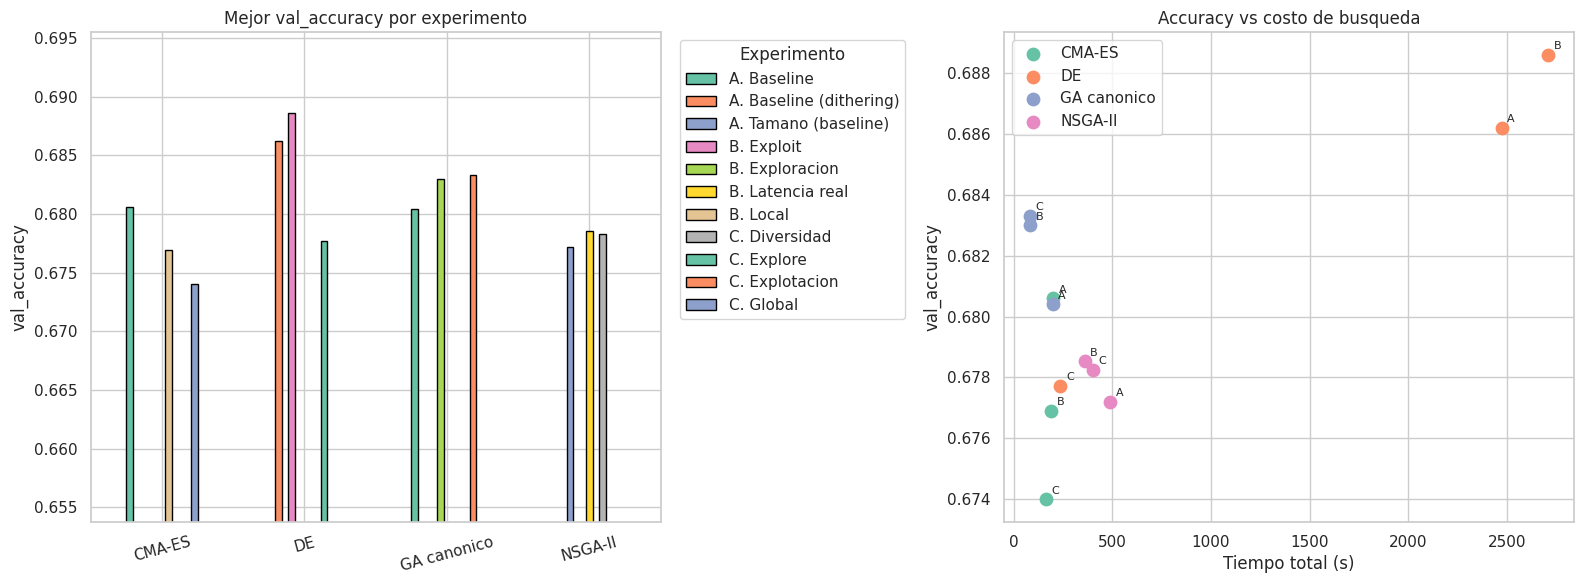

In [10]:
# Barras: val_acc por experimento agrupado por algoritmo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot = results_df.pivot(index="algo", columns="experimento", values="best_val_acc")
pivot.plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Mejor val_accuracy por experimento")
axes[0].set_ylabel("val_accuracy")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Experimento", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0].set_ylim(results_df["best_val_acc"].min() * 0.97,
                  results_df["best_val_acc"].max() * 1.01)

# Scatter: acc vs tiempo total del experimento
for algo, sub in results_df.groupby("algo"):
    axes[1].scatter(sub["time_s"], sub["best_val_acc"], s=80, label=algo)
    for _, r in sub.iterrows():
        axes[1].annotate(r["experimento"].split(".")[0],
                         (r["time_s"], r["best_val_acc"]),
                         fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("Tiempo total (s)")
axes[1].set_ylabel("val_accuracy")
axes[1].set_title("Accuracy vs costo de busqueda")
axes[1].legend()

plt.tight_layout()
plt.show()

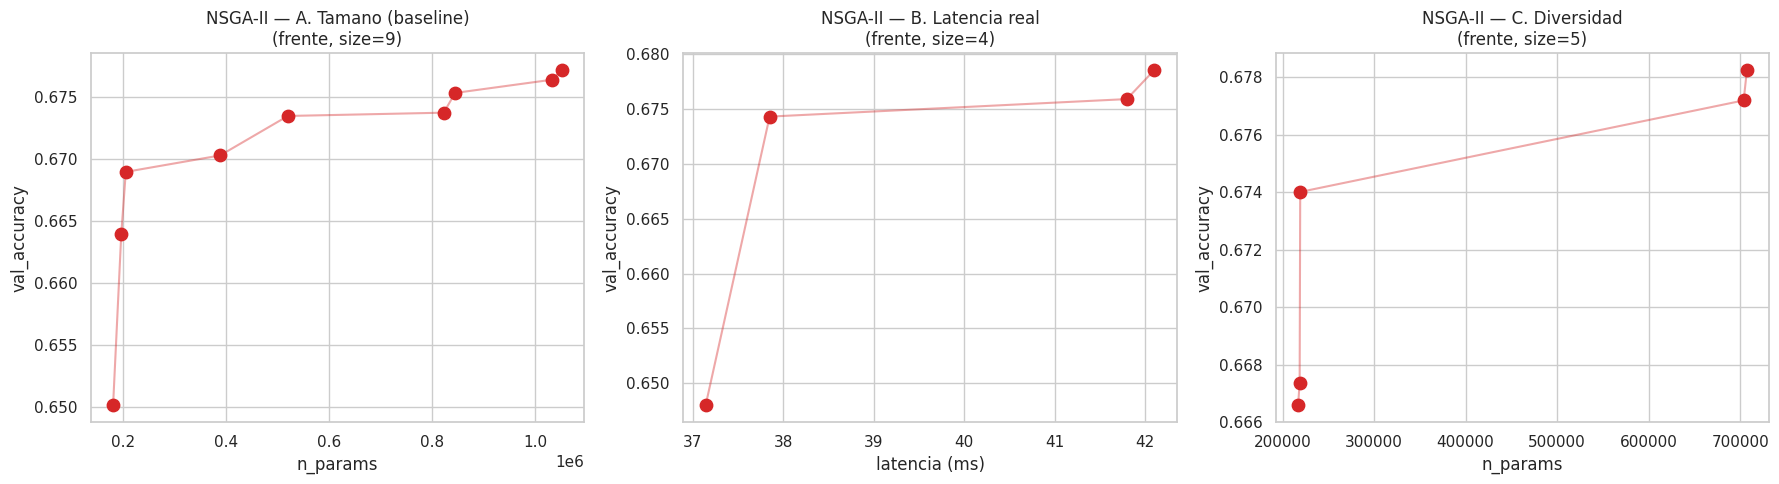

In [11]:
# Frentes de Pareto NSGA-II: una figura con los 3 frentes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (exp_name, (front, second_obj)) in zip(axes, NSGA_FRONTS.items()):
    pts = np.array([[ind.fitness.values[0], ind.fitness.values[1]]
                    for ind in front])
    pts = pts[pts[:, 1].argsort()]
    ax.scatter(pts[:, 1], pts[:, 0], s=80, color="tab:red")
    ax.plot(pts[:, 1], pts[:, 0], color="tab:red", alpha=0.4)
    xlabel = "n_params" if second_obj == "n_params" else "latencia (ms)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel("val_accuracy")
    ax.set_title(f"NSGA-II — {exp_name}\n(frente, size={len(front)})")

plt.tight_layout()
plt.show()

## 9. Analisis por algoritmo

Interpretacion tipica de los resultados (puede variar segun la corrida):

### GA canonico
- **Baseline vs Exploracion:** presion baja (tournsize=2) y mucho cruce suele producir poblaciones mas diversas. Bueno en espacios con multiples modos.
- **Explotacion** (tournsize=5, mutacion 0.5) tiende a converger mas rapido pero se queda en un optimo si la mutacion no descompone demasiado al mejor.

### CMA-ES
- `sigma0=0.1` converge rapido si `x0=[0.5]*7` esta cerca del optimo — arriesgado en problemas multimodales.
- `sigma0=0.5` explora mejor pero gasta presupuesto; con solo 3 generaciones puede no tener tiempo de estrechar.
- `sigma0=0.3` (baseline) suele ser el compromiso robusto.

### DE
- **Exploit (F=0.5, CR=0.9, best1bin):** convergencia rapida hacia el mejor actual. Riesgo: estancamiento prematuro.
- **Explore (F=0.9, CR=0.3, rand1bin):** gran diversidad, buen comportamiento en paisajes rugosos; necesita mas presupuesto para convergir.
- **Dithering** suele ser el default mas robusto porque `F` varia entre iteraciones.

### NSGA-II
- **Tamano vs Latencia:** dan frentes distintos. Un modelo con menos parametros NO siempre es mas rapido (depende de shapes), y viceversa. El frente de latencia es el relevante si el objetivo es deployment.
- **Diversidad (cxpb=0.6):** reduce la propagacion del elite y puede dar frentes mas amplios pero menos optimizados.

## 10. Conclusiones

- Todos los algoritmos encuentran configuraciones comparables en este presupuesto corto; CMA-ES y DE suelen converger mejor con pocas evaluaciones.
- Para producir **frentes de Pareto realistas en deployment**, NSGA-II con latencia medida es mas informativo que con conteo de parametros.
- Los ejes mas sensibles observados son: `n_hidden1`, `lr` y `dropout1`. Si se quiere un taller mas contundente, restringir los rangos a esos 3 hiperparametros y aumentar `pop/gen` amplifica diferencias.